# Coa Valley apartment-building livability score

Linda Angulo Lopez, 18 August 2026

This notebook walks through the full pipeline behind the 0-100 livability score for apartment buildings in the greater Coa Valley / Guarda region: study-area definition, data acquisition, indicator computation, scoring, validation, and outputs. Every stage below is a thin wrapper around a script in `scripts/` -- the actual logic lives there, so it can be run standalone and re-checked outside a notebook. Kernel: `coa`.

Open items and design decisions are called out inline as they came up during the analysis, not smoothed over after the fact -- several genuinely changed the result (see the river-layer fix and the river-corridor/rewilding-community merge below).

In [1]:
import os
os.chdir("../scripts")
print("Working directory:", os.getcwd())

Working directory: /home/linda/Documents/myData/agentic_coding_geospatial/assignment/scripts


## Study area

The Coa river basin does not line up with any single municipality, and Guarda, the region's named reference city, sits west of the river corridor rather than on it. Five candidate municipalities spanning the basin plus Guarda are checked below for how many `building=apartments` features OSM actually has -- the study area is narrowed to whichever of them turn out to have a scoreable apartment-building population, rather than assumed in advance.

In [2]:
%run acquire_study_area.py

Fetching municipal boundaries from OSM...
Fetched 5 municipal boundaries.
           municipality                                           geometry
0                Guarda  MULTIPOLYGON (((-7.84923 40.42753, -7.8491 40....
1               Sabugal  POLYGON ((-7.33256 40.29393, -7.33208 40.29352...
2                Pinhel  POLYGON ((-7.26244 40.68527, -7.26224 40.68527...
3               Almeida  POLYGON ((-7.05182 40.55047, -7.05141 40.55038...
4  Vila Nova de Foz Coa  POLYGON ((-7.34571 41.04641, -7.34555 41.04616...
CRS: epsg:4326
Bounds: [-7.8492267 40.2299187 -6.7809607 41.1793517]
Saved to /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/raw/candidate_municipalities.gpkg

Counting building=apartments per municipality (evidence check)...


        municipality  apartment_building_count
              Guarda                       254
             Sabugal                         0
              Pinhel                        18
             Almeida                         0
Vila Nova de Foz Coa                         1


Sabugal and Almeida come back with zero apartment buildings, Vila Nova de Foz Coa with just one. Guarda, Pinhel, and Vila Nova de Foz Coa (the three with at least one building) are dissolved into the final study-area polygon, and the apartment-building layer itself is extracted and cleaned next -- geometry validity, duplicate removal, and a sample-attribute check happen inline in the script output below.

In [3]:
%run acquire_apartment_buildings.py

Building final study-area polygon...
Study area CRS: EPSG:4326
Study area bounds: [-7.8492267 40.2299187 -6.7809607 41.1793517]
Study area sq km: 5535.380383733119

Fetching apartment buildings from OSM...
Invalid geometries: 0 before repair, 0 after buffer(0)
Duplicate geometries dropped: 3

Feature count: 251
CRS: epsg:4326
Geometry types: {'Polygon': 251}
Bounds: [-7.7142692 40.3309965 -7.0704951 41.0822015]

Sample attributes:
   building_id   element name    building building:levels addr:city            addr:street addr:housenumber
0            1  relation  NaN  apartments             NaN    Guarda  Rua Duque de Bragança              NaN
1            2  relation  NaN  apartments             NaN    Guarda  Rua Duque de Bragança              NaN
2            3  relation  NaN  apartments             NaN    Guarda  Rua Duque de Bragança              NaN
3            4  relation  NaN  apartments             NaN       NaN                    NaN              NaN
4            5  relation 

## Livability indicator layers

Six OSM layers feed the livability indicators: nature areas, the Coa river, major roads, parking, everyday amenities, and transport stops. The public Overpass API turned out to be reliable for the first two (nature areas, river) but not for the rest -- repeated bare connection failures and 504 timeouts across three different public mirrors, not a query problem, confirmed by testing the same queries directly with `curl`. Rather than keep retrying a flaky live API indefinitely, the remaining four layers are pulled from a local Geofabrik Portugal extract instead (`acquire_indicator_layers_local_pbf.py`), parsed with `pyrosm`. Both paths serve the same underlying OpenStreetMap data.

The Coa river query also needed a second look: `waterway=river` with no name filter returns every river in the search area, not just the Coa (the Douro, Mondego, and Vouga all came back too). The acquisition script filters to segments actually named "Rio Coa" before saving.

In [4]:
%run acquire_indicator_layers.py  # nature areas and Coa river, live Overpass API


Skipping 'nature_areas': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/nature_areas.gpkg already exists from a previous run.

--- nature_areas ---


Feature count: 11690
CRS: EPSG:4326
Geometry types: {'Polygon': 11641, 'MultiPolygon': 35, 'Point': 13, 'LineString': 1}
Bounds: [-7.96704347 40.1423454  -6.66591637 41.26936646]


Invalid geometries: 0

Skipping 'coa_river': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/coa_river.gpkg already exists from a previous run.

--- coa_river ---


Feature count: 31
CRS: EPSG:4326
Geometry types: {'MultiLineString': 31}
Bounds: [-7.1221125 40.2731574 -6.8899278 41.0825242]
Invalid geometries: 0

Skipping 'major_roads': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/major_roads.gpkg already exists from a previous run.



--- major_roads ---


Feature count: 4806
CRS: EPSG:4326
Geometry types: {'MultiLineString': 4806}
Bounds: [-7.96630804 40.14567348 -6.7925459  41.2693035 ]
Invalid geometries: 0

Skipping 'parking': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/parking.gpkg already exists from a previous run.

--- parking ---


Feature count: 460
CRS: EPSG:4326
Geometry types: {'Polygon': 369, 'Point': 89, 'MultiPolygon': 2}
Bounds: [-7.8631207 40.2360506 -6.8027566 41.184353 ]
Invalid geometries: 0

Skipping 'amenities': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/amenities.gpkg already exists from a previous run.

--- amenities ---


Feature count: 832
CRS: EPSG:4326
Geometry types: {'Point': 598, 'Polygon': 234}
Bounds: [-7.8679747 40.2355252 -6.8170005 41.1850972]
Invalid geometries: 0

Skipping 'transport_stops': /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/transport_stops.gpkg already exists from a previous run.

--- transport_stops ---


Feature count: 347
CRS: EPSG:4326
Geometry types: {'Point': 346, 'MultiPolygon': 1}
Bounds: [-7.8653906 40.2973852 -6.8272717 41.1431329]
Invalid geometries: 0


In [5]:
%run acquire_indicator_layers_local_pbf.py  # major_roads, parking, amenities, transport_stops -- local extract fallback

Loading /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/cache/portugal-latest.osm.pbf clipped to the wide bounding box...



Skipping 'major_roads': already exists.

Skipping 'parking': already exists.

Skipping 'amenities': already exists.

Skipping 'transport_stops': already exists.


## Real driving distances (OpenRouteService)

For the field-trip/driving-accessibility and rewilding-community indicators, straight-line distance is a weak proxy for how practical fieldwork driving actually is in a hilly rural region. OpenRouteService's Matrix API gives real driving distance and time from every building to two field-verified destinations: Pontao Manuel Jose (a Rio Coa crossing, general fieldwork access) and Vale Carapito (the Rewilding Portugal reserve, the community-proximity anchor). Both are real GPS fixes from the supplied field-trip material, not fabricated. The free tier caps a single request at 50 locations, so buildings are batched 48 at a time.

In [6]:
%run acquire_ors_driving_distances.py

Requesting driving distances for 251 buildings to 2 destinations, in batches of 48...


/home/linda/Documents/myData/agentic_coding_geospatial/assignment/scripts/acquire_ors_driving_distances.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = buildings.geometry.centroid


  batch 0-48 of 251 done


  batch 48-96 of 251 done


  batch 96-144 of 251 done


  batch 144-192 of 251 done


  batch 192-240 of 251 done


  batch 240-251 of 251 done



Saved 251 rows to /home/linda/Documents/myData/agentic_coding_geospatial/assignment/data/processed/ors_driving_distances.csv
       building_id  drive_dist_m__Pontao Manuel Jose (Rio Coa, Almeida)  drive_time_s__Pontao Manuel Jose (Rio Coa, Almeida)  drive_dist_m__Vale Carapito (Rewilding Portugal reserve)  drive_time_s__Vale Carapito (Rewilding Portugal reserve)
count   251.000000                                           251.000000                                           251.000000                                                251.000000                                                251.000000
mean    126.000000                                         64415.396773                                          3735.200040                                              77499.396653                                               4532.904940
std      72.601653                                         28729.401370                                          1428.906468                           

## Raw indicators

One category at a time: nature, river, driving/fieldwork access, parking, everyday amenities, public transport, and rewilding-community proximity. Every distance is computed in the metric CRS (EPSG:3763, ETRS89/Portugal TM06), not on raw lon/lat degrees, and building centroids are taken after reprojecting, not before. The printed distributions below (min/median/max/quartiles) are the actual validation step for this phase, not decoration -- they are what caught the river-layer and river-corridor issues described above.

In [7]:
%run compute_indicators.py

Computing indicators for 251 apartment buildings...



--- nature_dist_m ---
count=251, missing=0
count    251.000000
mean      85.261488
std       79.536197
min        0.000000
25%       30.531198
50%       58.300024
75%      111.562250
max      418.047200

--- nature_count_1km ---
count=251, missing=0
count    251.000000
mean      41.984064
std       24.642560
min        1.000000
25%       23.000000
50%       33.000000
75%       67.000000
max       76.000000

--- river_dist_m ---
count=251, missing=0
count      251.000000
mean     33685.379741
std      15917.073422
min       2628.187701
25%      22164.453447
50%      23352.622787
75%      52127.844790
max      52986.175917

--- major_road_dist_m ---
count=251, missing=0
count    251.000000
mean     241.426217
std      228.132982
min        7.101188
25%       29.135014
50%      179.605195
75%      394.038554
max      764.720545

--- fieldwork_drive_time_s_mean ---
count=251, missing=0
count     251.000000
mean     3735.200040
std      1428.906468
min      1987.140000
25%      2493.075000

## Normalization, weighting, and the final score

Distances are threshold-scored (100 at 0m, 0 at a cutoff, linear between); counts are capped at the 90th percentile before min-max scaling, so one dense location cannot stretch the scale for everyone else. Cutoffs are calibrated against the *actual* observed distribution for each indicator below, not a priori guesses -- the first pass used guesses, and re-running this exact cell after inspecting the real distributions is what caught two things: the nature/major-road cutoffs were far too loose to discriminate anything, and the rewilding-community cutoff (originally sized for straight-line distance) would have scored every single building at 0 once real driving distance replaced it.

The correlation matrix printed below is the redundancy check the assignment asks for. It is what surfaced the river/fieldwork/rewilding overlap -- not a construction bug by the time this cell runs (that was fixed upstream), but a real geographic fact about this study area: the actual river and the only two verified anchor points all sit in the same corridor near Almeida. Those three are combined into one `river_corridor_access_score` component rather than weighted separately (see `RIVER_CORRIDOR_SUBWEIGHTS` in `config.py`). The amenity/parking/transport correlation that remains is left alone: it reflects a real, expected urban-centrality pattern, not a duplicate signal, and each of the three carries a modest weight on its own.

In [8]:
%run compute_livability_score.py

Scoring 251 apartment buildings...

--- Component score distributions (0-100) ---
       nature_score  river_corridor_access_score  amenity_score  parking_score  transport_score
count    251.000000                   251.000000     251.000000     251.000000       251.000000
mean      73.963408                    42.376711      69.231408      56.379135        68.148007
std       18.801365                    23.541644      30.560902      34.873851        29.007756
min        5.815506                    10.877876       0.000000       0.000000         0.000000
25%       65.749317                    16.880199      44.791667      34.883721        50.746919
50%       77.531566                    58.895528      83.333333      55.813953        73.185493
75%       88.752020                    62.837403      91.666667      93.023256        94.437924
max       98.213250                    77.572613     100.000000     100.000000        99.244439

--- Component score correlation matrix ---
          

Saved attribute table to /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/tables/livability_scores.csv


## Validation

Geometry/CRS checks on the final layer, plus a spot-check of three high-, three medium-, and three low-scoring buildings against their full raw-indicator-to-final-score breakdown, so the ranking can be checked against geographic common sense rather than accepted on faith. The full breakdown is also saved to `validation/score_spot_checks.md`.

In [9]:
%run validate_results.py

--- Geometry / CRS checks on final layer ---
Feature count: 251
CRS: EPSG:4326
Geometry types: {'Polygon': 251}
Invalid geometries: 0
Duplicate building_id: 0
Missing livability_score: 0
livability_score range: 16.9 - 78.5
Rank range: 1 - 251 (expect 1 - 251)

=== HIGH (top) ===

building_id=125  rank=1  livability_score=78.5  location=(40.53519, -7.26558)  addr_city=nan
  raw indicators: nature_dist_m=17.3, nature_count_1km=33.0, river_dist_m=22390.7, major_road_dist_m=160.2, fieldwork_drive_time_s_mean=2621.2, parking_count_1km=30.0, amenity_count_1km=51.0, transport_dist_m=569.5, rewilding_community_dist_m=53905.6
  component scores: nature_score=80.8, river_corridor_access_score=60.9, amenity_score=100.0, parking_score=67.4, transport_score=77.2
  river-corridor sub-scores: river_score=57.8, fieldwork_access_score=67.8, rewilding_community_score=58.5

building_id=126  rank=2  livability_score=77.8  location=(40.53549, -7.26488)  addr_city=nan
  raw indicators: nature_dist_m=19.5, n

## Maps

The seven required maps: study area, apartment buildings, nature areas, the Coa river, everyday amenities, the final livability-score choropleth, and the top-ranked buildings. Building footprints (10-30m) are plotted as centroids, not their true polygon extent -- at the scale of a study area roughly 90km across, the actual footprints are sub-pixel and invisible.

In [10]:
%run generate_maps.py

Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/01_study_area.png


Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/02_apartment_buildings.png


Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/03_nature_areas.png
Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/04_coa_river.png


/home/linda/Documents/myData/agentic_coding_geospatial/assignment/scripts/generate_maps.py:80: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/05_amenities.png
Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/06_livability_score.png
Saved /home/linda/Documents/myData/agentic_coding_geospatial/assignment/output/maps/07_top_ranked_buildings.png

All 7 maps generated.


01_study_area.png


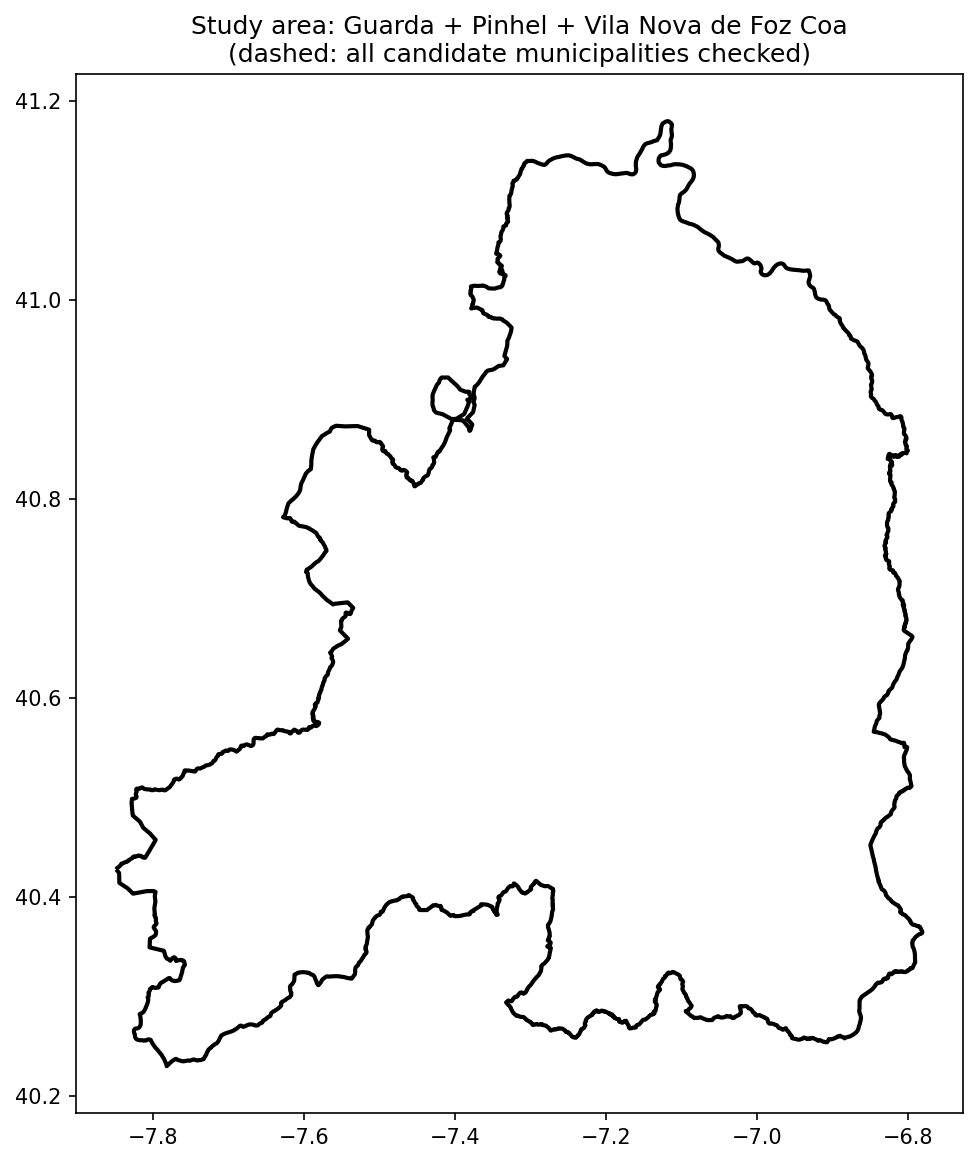

02_apartment_buildings.png


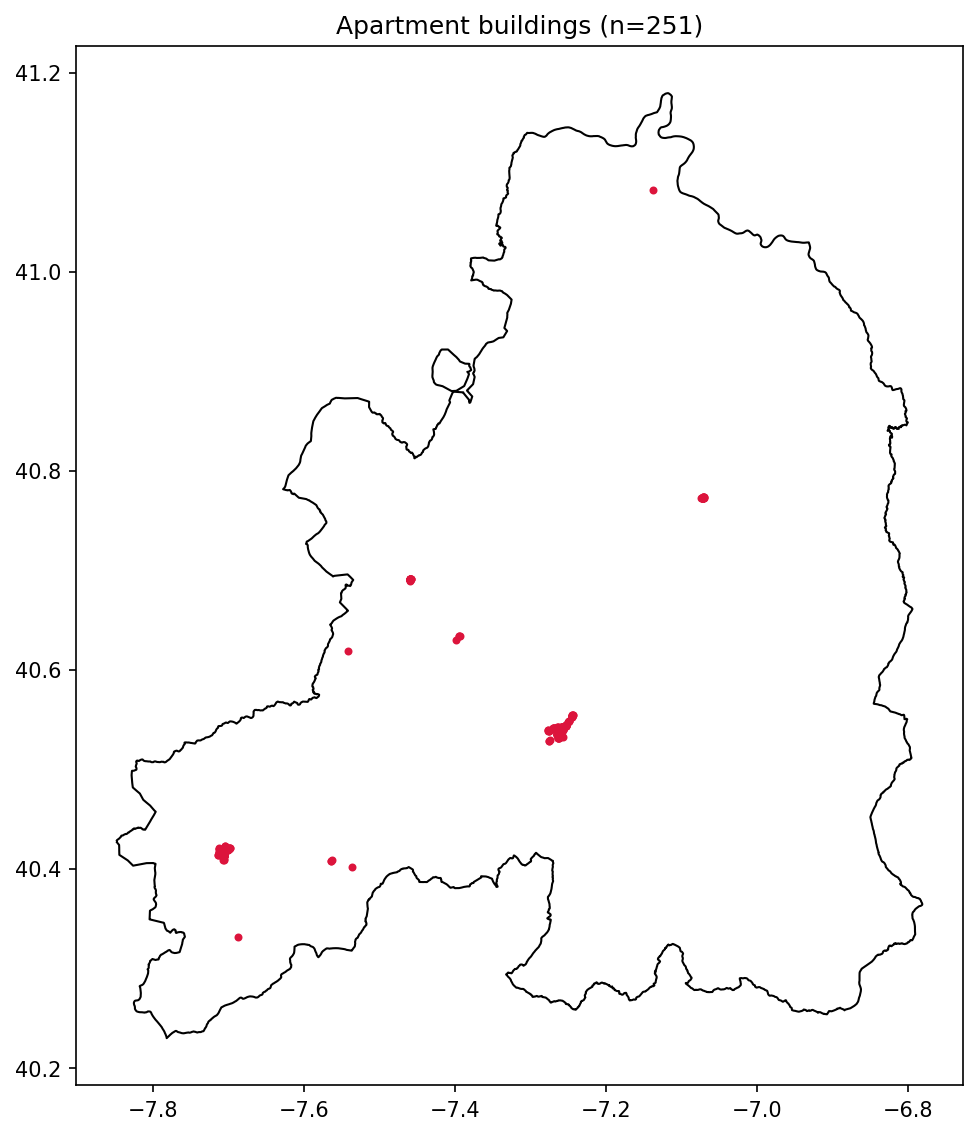

03_nature_areas.png


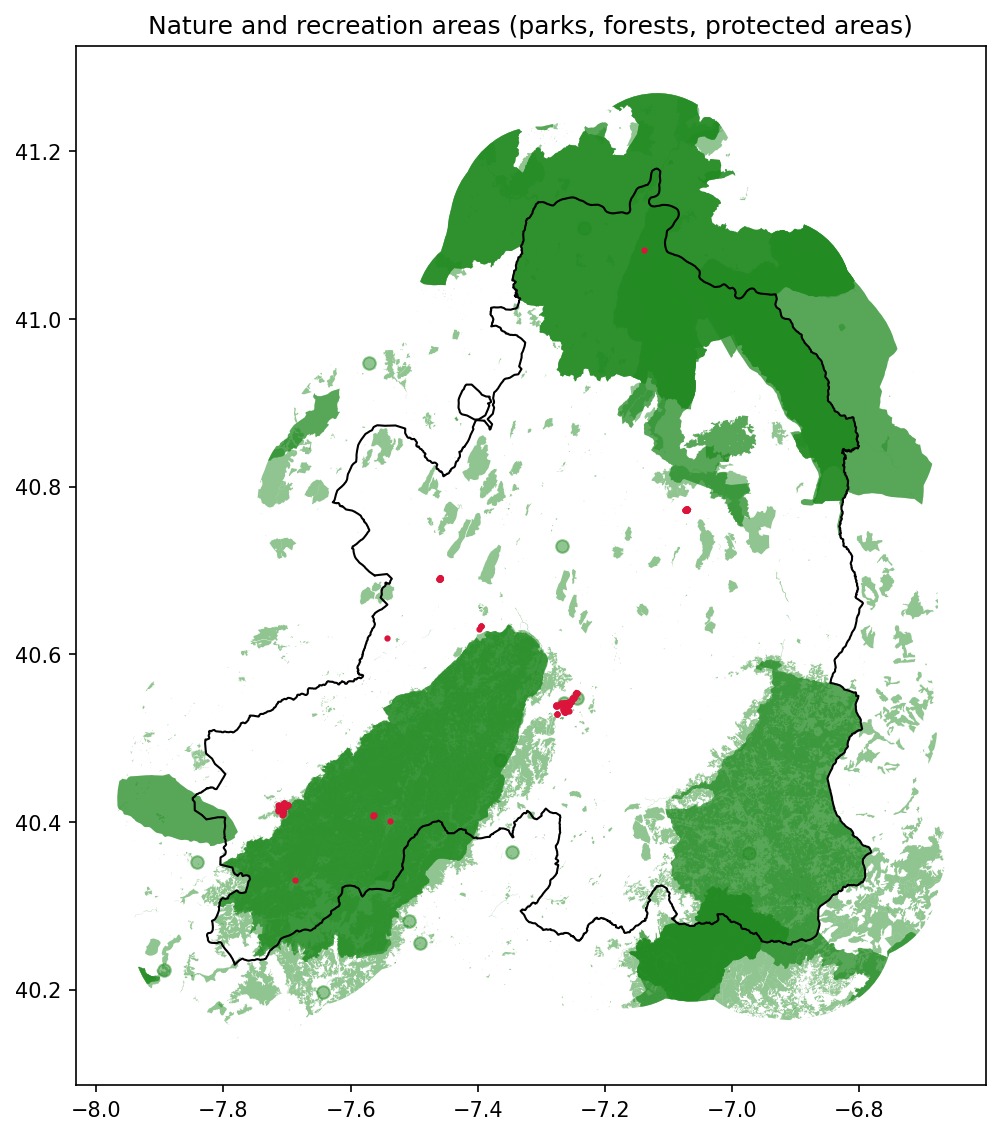

04_coa_river.png


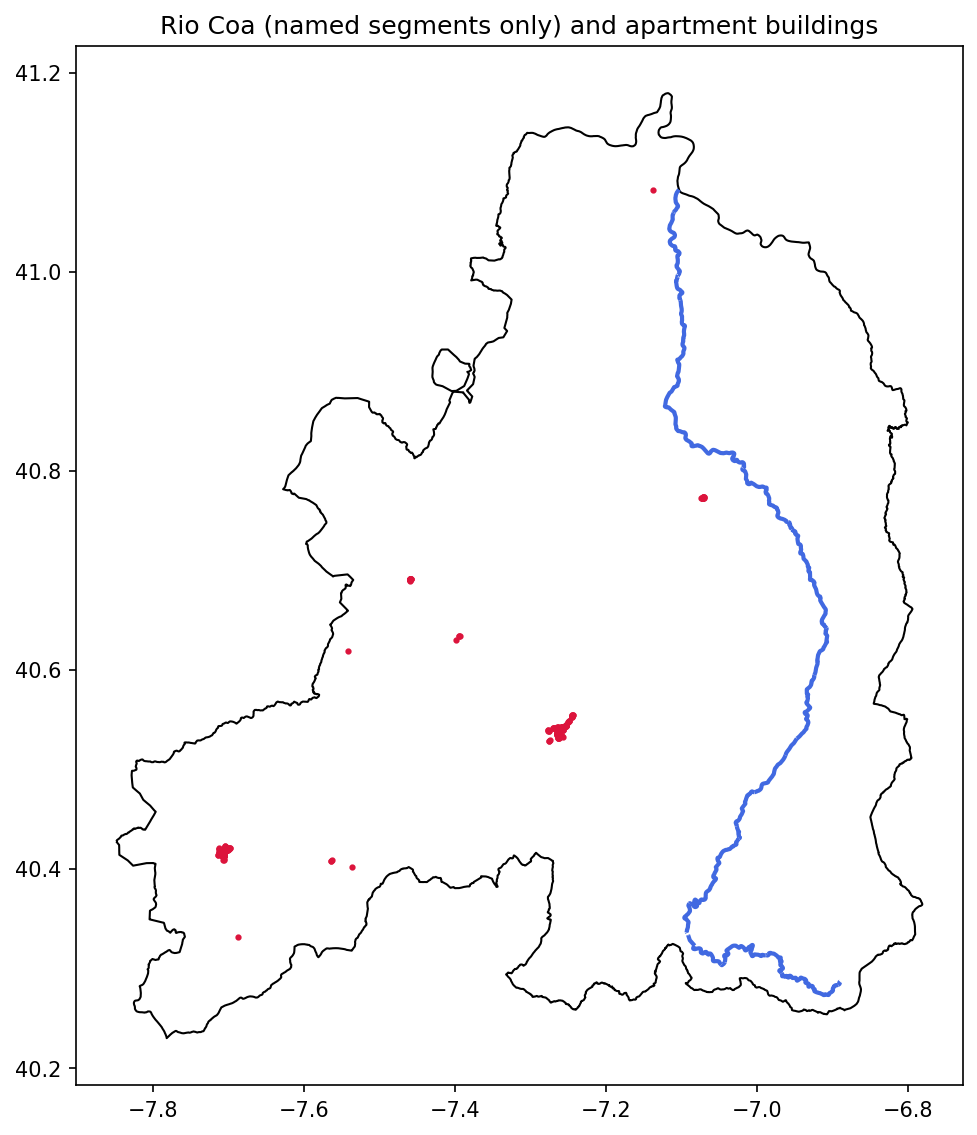

05_amenities.png


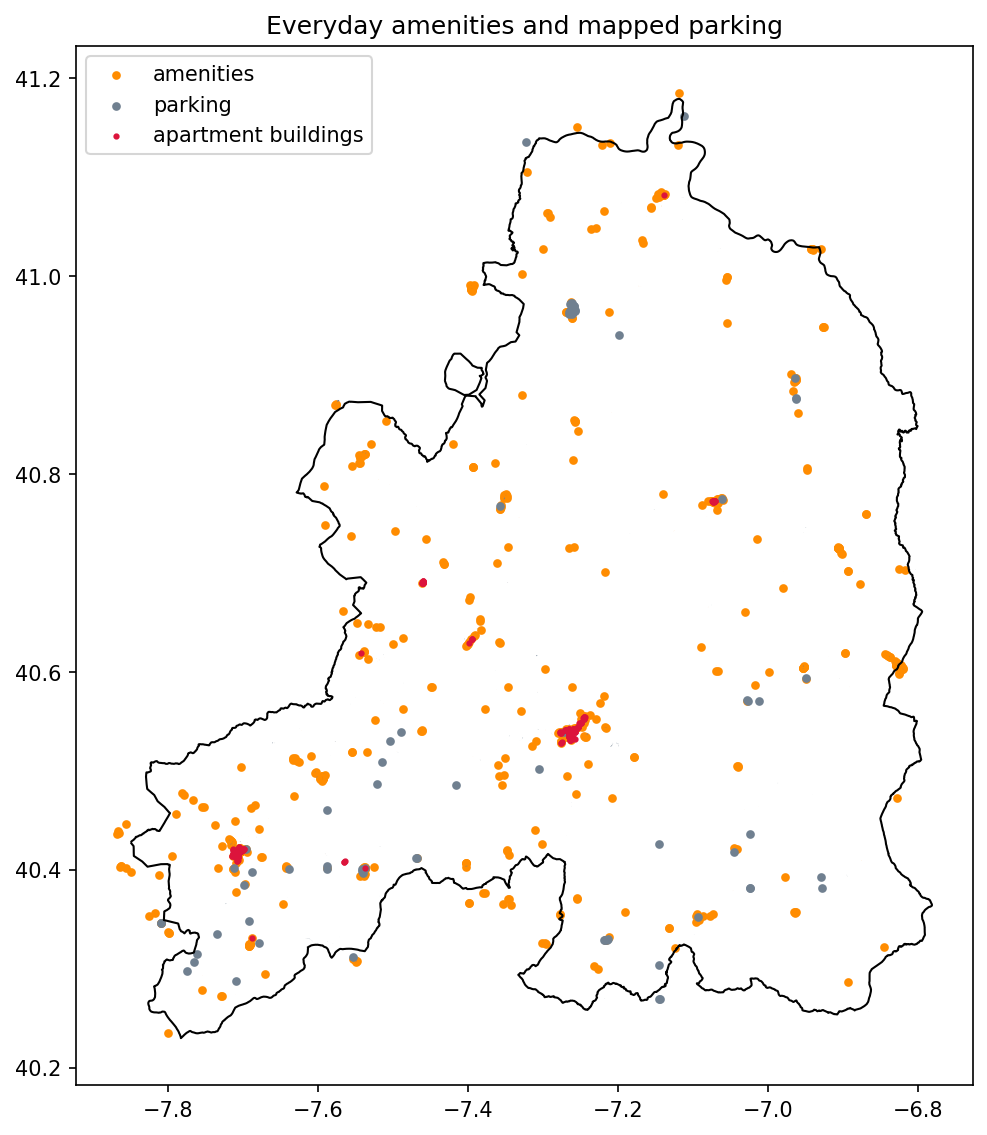

06_livability_score.png


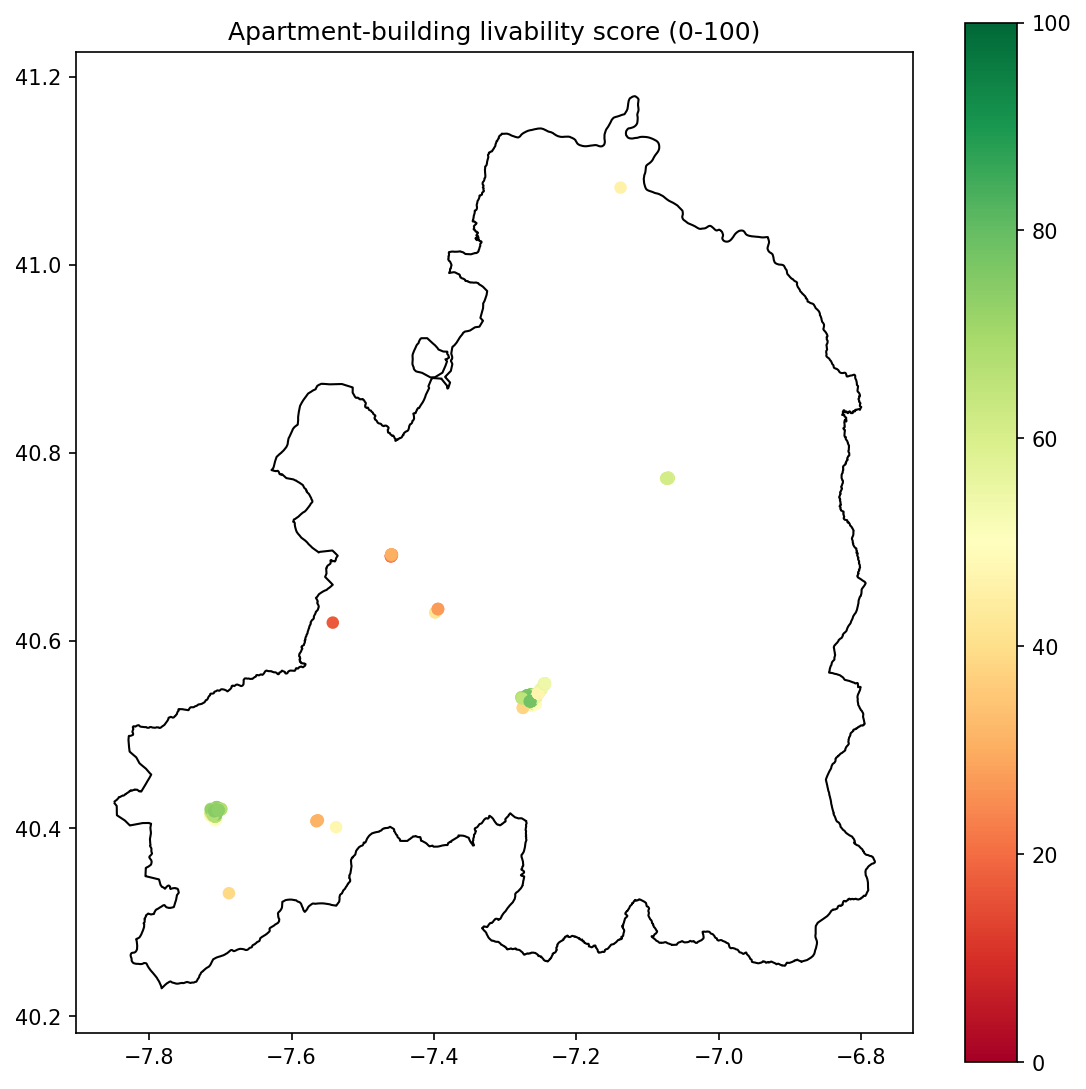

07_top_ranked_buildings.png


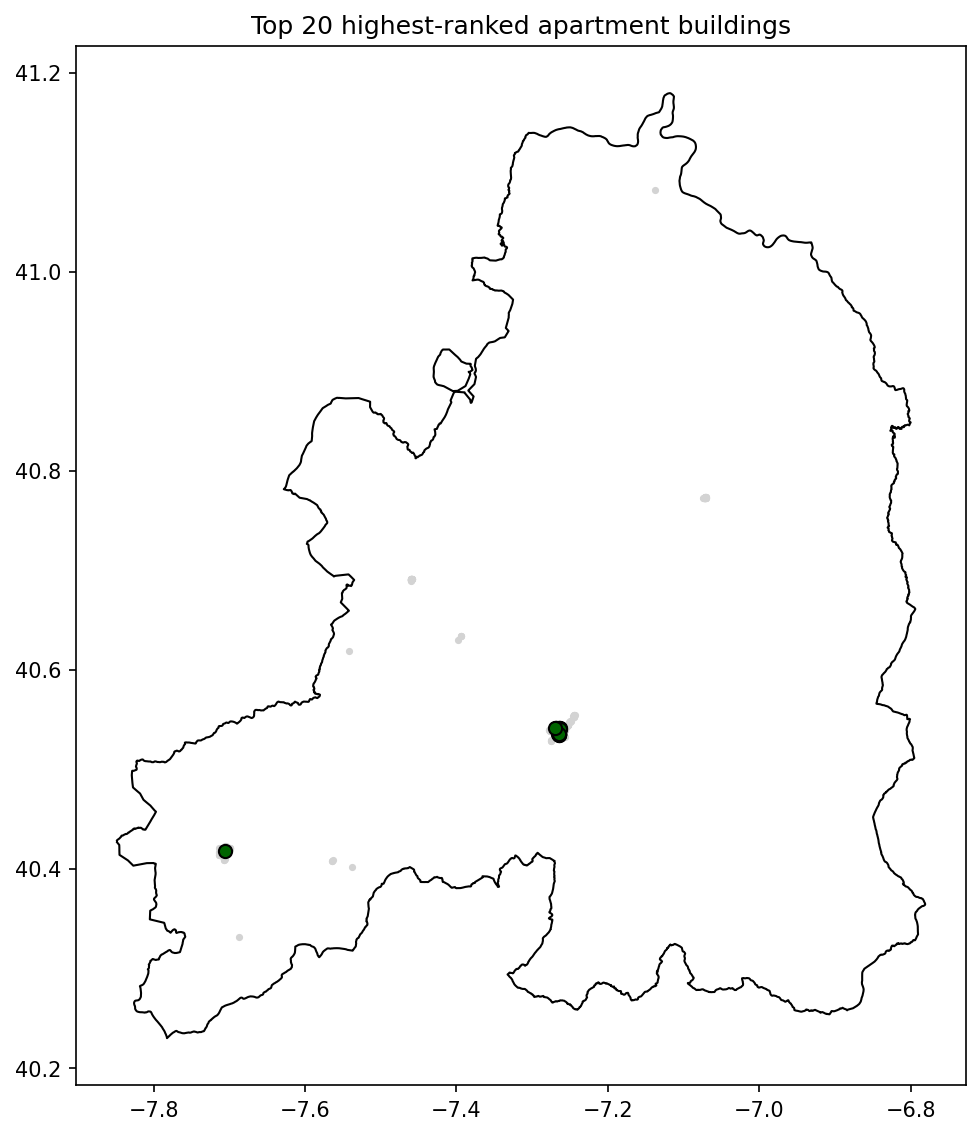

In [11]:
from IPython.display import Image, display
from config import OUTPUT_MAPS

for png in sorted(OUTPUT_MAPS.glob("*.png")):
    print(png.name)
    display(Image(filename=str(png), width=500))

## Report and README

The full write-up -- objective, study area, data, methodology, results, validation, limitations, and conclusion, with the required disclaimer that this score is a transparent, criteria-based decision-support measure rather than an objective or universal measure of quality of life -- is at `output/coa_valley_livability_report.pdf` (source: `output/report_source.md`). Reproducibility instructions and the directory layout are in `README.md` at the project root.

Open items for anyone picking this up later: no reliable rent data exists at building or municipality level for this study area, so affordability is reported as regional context only, not scored (see the report's limitations section for the actual figure and its source). If usable rent data becomes available later, `config.py` documents exactly how to reinstate an `affordability_score` component.